<a href="https://colab.research.google.com/github/noor7475/Titanic-Decision-Tree-Classifier/blob/main/Titanic_Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup: To run this notebook, please download the Titanic_Data.csv from my GitHub and upload it to the "Files" folder on the left sidebar of this Colab page.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Titanic_Data.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [ ]:
df.shape

(418, 12)

# Finding missing values




In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB




# No duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for i in df.columns:
  print(df[i].value_counts())
  print()

PassengerId
1309    1
892     1
1293    1
1292    1
1291    1
       ..
898     1
897     1
896     1
895     1
894     1
Name: count, Length: 418, dtype: int64

Survived
0    266
1    152
Name: count, dtype: int64

Pclass
3    218
1    107
2     93
Name: count, dtype: int64

Name
Peter, Master. Michael J                        1
Kelly, Mr. James                                1
Gale, Mr. Harry                                 1
Bonnell, Miss. Caroline                         1
Conlon, Mr. Thomas Henry                        1
                                               ..
Connolly, Miss. Kate                            1
Svensson, Mr. Johan Cervin                      1
Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1
Wirz, Mr. Albert                                1
Myles, Mr. Thomas Francis                       1
Name: count, Length: 418, dtype: int64

Sex
male      266
female    152
Name: count, dtype: int64

Age
21.0    17
24.0    17
22.0    16
30.0    15
18.0    13
        ..

# Identifying garbage values in object dtype columns

In [ ]:
for i in df.select_dtypes(include='object').columns:
  print(df[i].value_counts())
  print()

Name
Peter, Master. Michael J                        1
Kelly, Mr. James                                1
Gale, Mr. Harry                                 1
Bonnell, Miss. Caroline                         1
Conlon, Mr. Thomas Henry                        1
                                               ..
Connolly, Miss. Kate                            1
Svensson, Mr. Johan Cervin                      1
Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1
Wirz, Mr. Albert                                1
Myles, Mr. Thomas Francis                       1
Name: count, Length: 418, dtype: int64

Sex
male      266
female    152
Name: count, dtype: int64

Ticket
PC 17608              5
CA. 2343              4
113503                4
347077                3
SOTON/O.Q. 3101315    3
                     ..
330972                1
7538                  1
3101298               1
315154                1
240276                1
Name: count, Length: 363, dtype: int64

Cabin
B57 B59 B63 B66    3
B45     

# Drop high cardinality columns

In [ ]:
df.drop(['Name', 'PassengerId', 'Ticket'], axis=1, inplace=True)

In [ ]:
df.describe(include='object')

,Sex,Cabin,Embarked
count,418,91,418
unique,2,76,3
top,male,B57 B59 B63 B66,S
freq,266,3,270


# Identifying object columns values with spaces

In [ ]:
df['Embarked'].str.startswith(' ').sum()
df['Embarked'].str.endswith(' ').sum()

np.int64(0)

In [ ]:
df['Sex'].str.startswith(' ').sum()
df['Sex'].str.endswith(' ').sum()

np.int64(0)

In [ ]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


# Histogram to Understand distribution

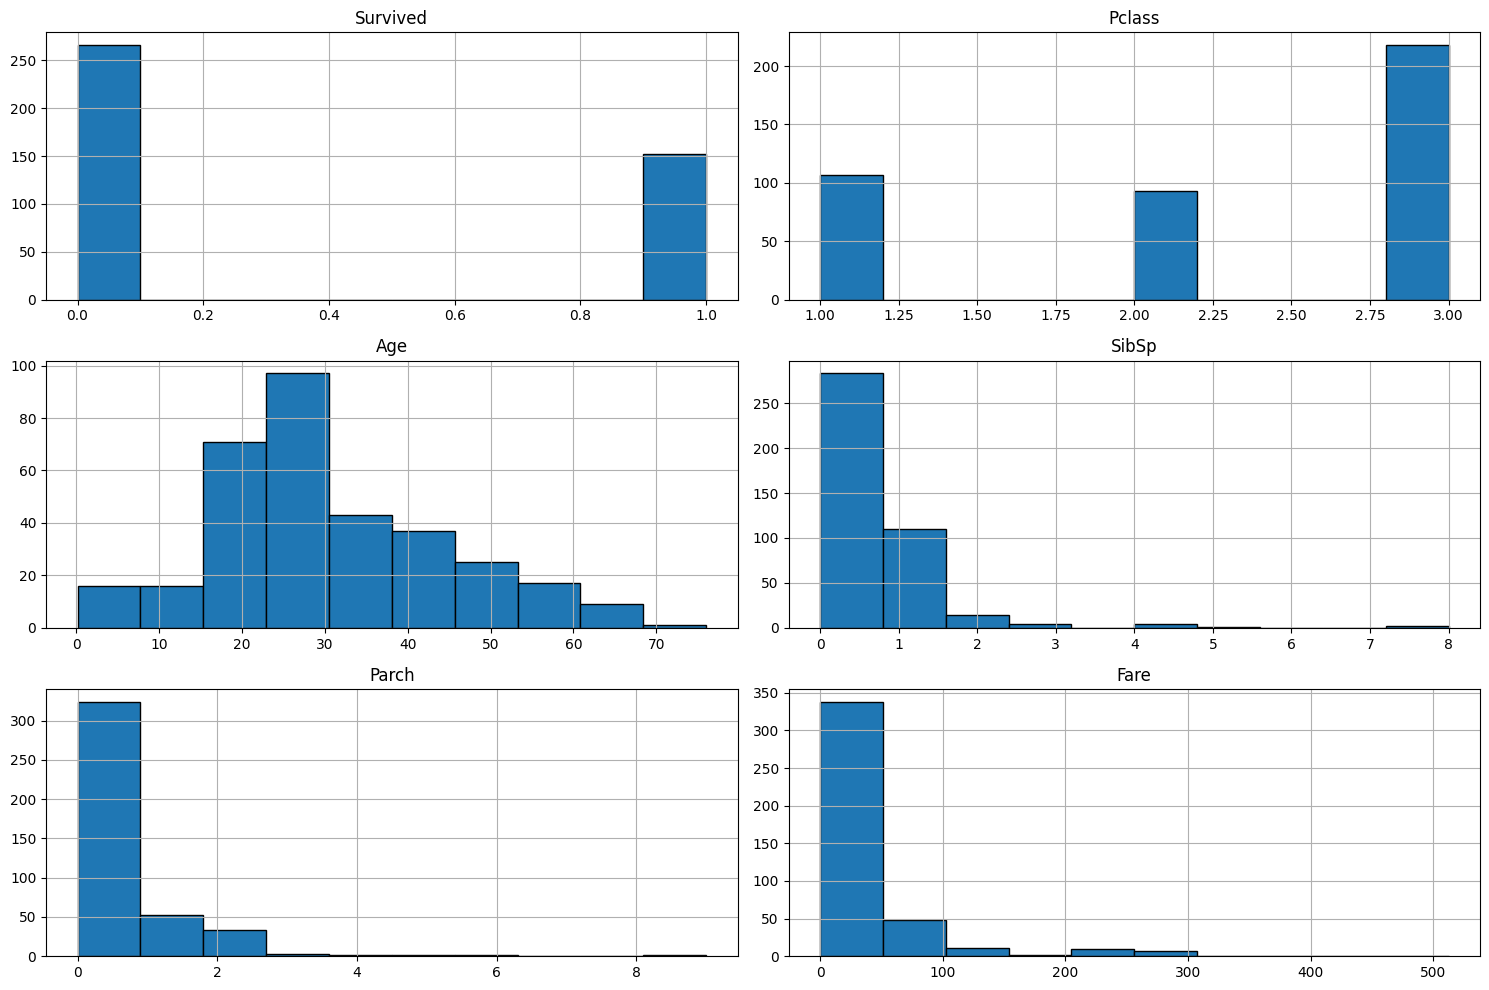

In [ ]:
df.select_dtypes(include='number').hist(figsize=(15,10), layout=(-1,2), edgecolor='black')
plt.tight_layout()
plt.show()


*   Target is imbalanced, more people died than survived, handle when initializing the model.

*   Different ditributions, but no need for scaling as also this does not affect decision trees.

# Boxplot to Identify outliers

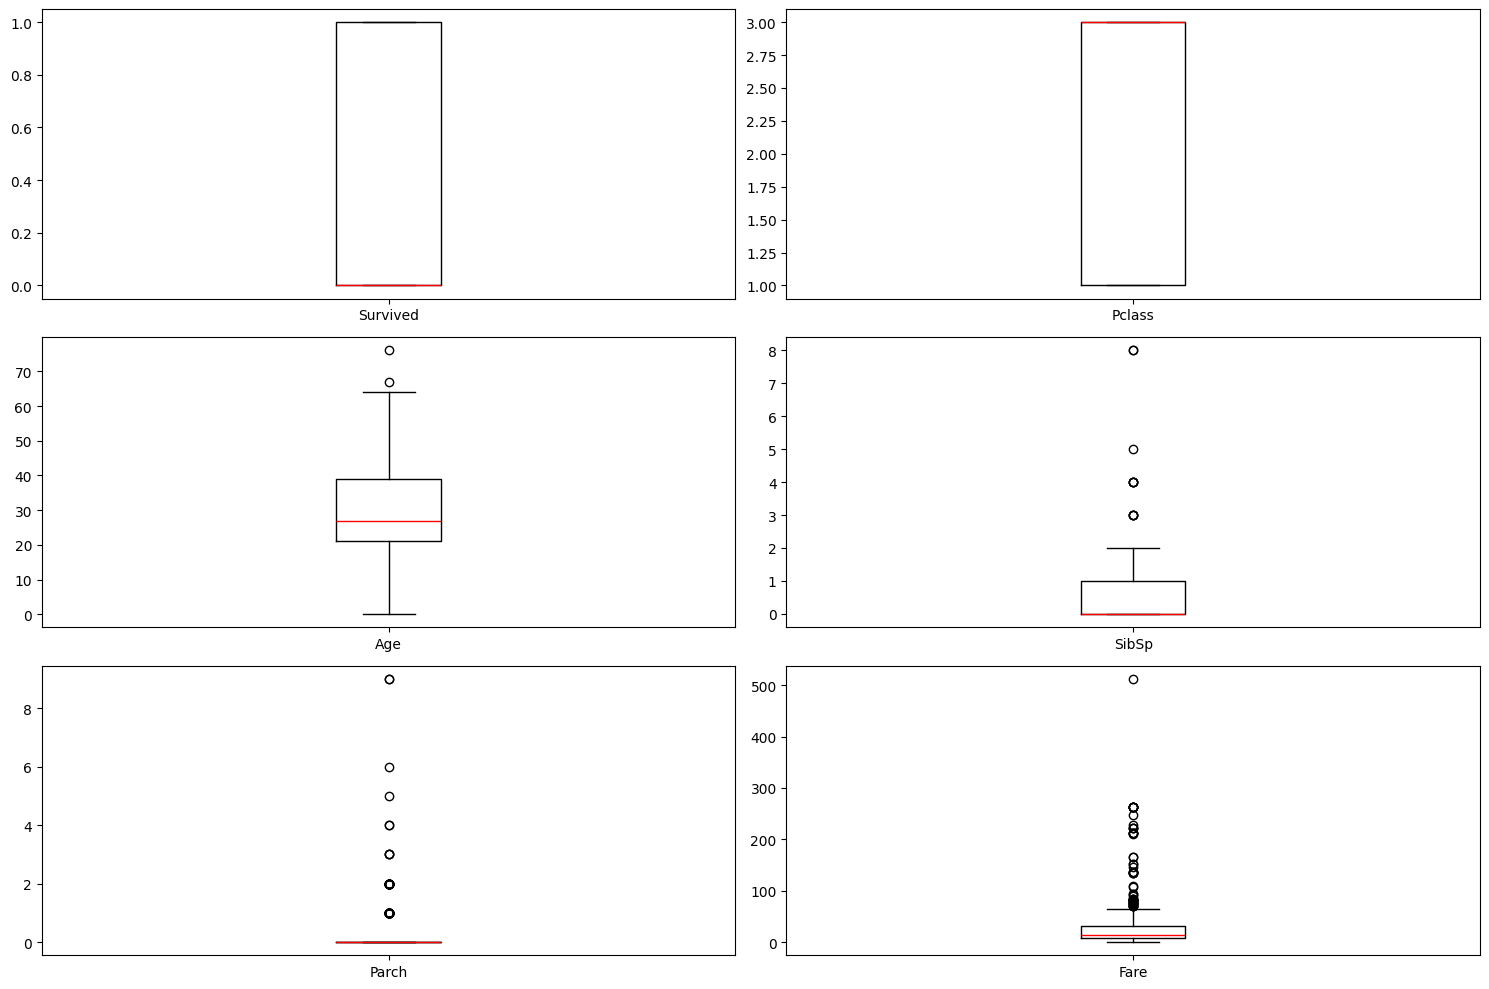

In [ ]:
df.select_dtypes(include='number').plot(kind='box', subplots=True, figsize=(15,10), layout=(-1,2), sharex=False, sharey=False, color=dict(boxes='black', whiskers='black',medians='red', caps='black'))
plt.tight_layout()
plt.show()

**decison trees are robust to outliers, so no need to handle them. But pruning the tree is needed to prevent overfitting.**

# Line plot to understand the relationship of numerical features

In [ ]:
df.select_dtypes(include='number').columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

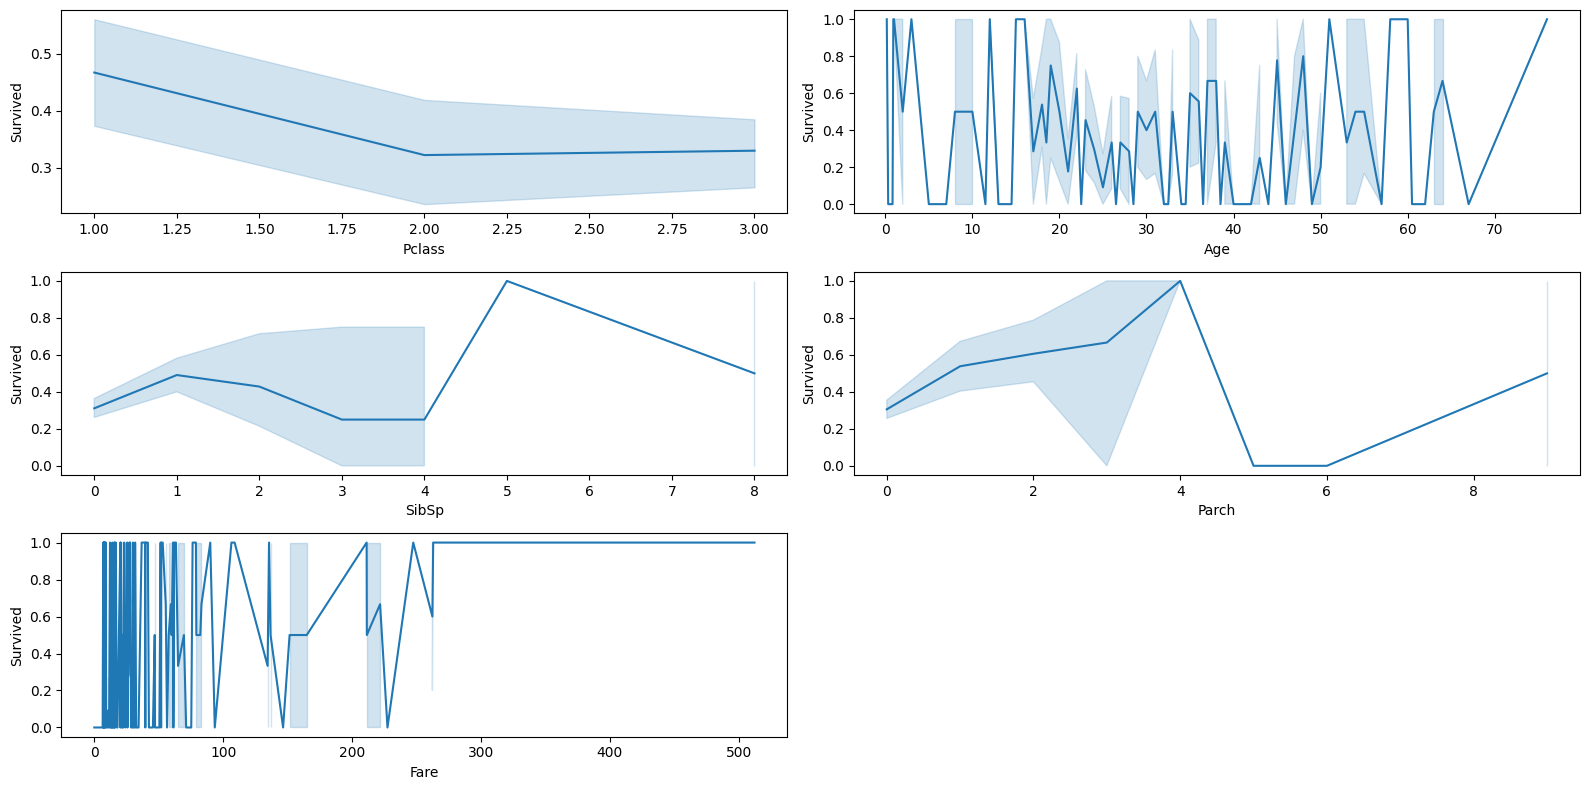

In [ ]:
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(3, 2, figsize=(16, 8))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.lineplot(data=df, x=feature, y='Survived', ax=axes[i])

fig.delaxes(axes[len(features)])

plt.tight_layout()
plt.show()

# Correlation with heatmap

In [ ]:
df.select_dtypes(include='number').corr()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.108615,-0.000013,0.099943,0.159120,0.191514
Pclass,-0.108615,1.000000,-0.492143,0.001087,0.018721,-0.577147
Age,-0.000013,-0.492143,1.000000,-0.091587,-0.061249,0.337932
SibSp,0.099943,0.001087,-0.091587,1.000000,0.306895,0.171539
Parch,0.159120,0.018721,-0.061249,0.306895,1.000000,0.230046
Fare,0.191514,-0.577147,0.337932,0.171539,0.230046,1.000000


<Axes: >

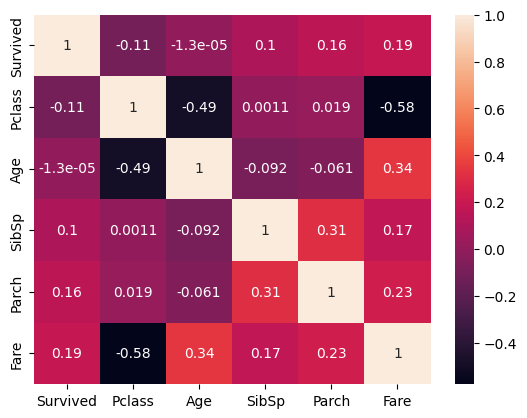

In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

*   Strong negative correlation between Pclass and Fare: redundant features, one of them can be removed. (Tested with both together and with each one alone, the best result was with both)
*   Moderate positive correlation between SibSp and Parch: a FamilySize feature can be created.


# Stacked bar plot to undersatnd the relationships of categorical features

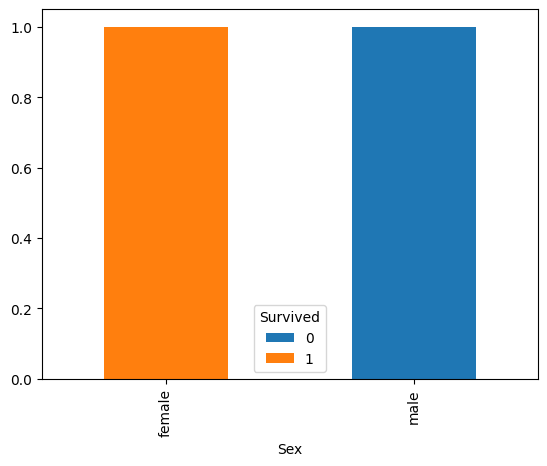

In [ ]:
pd.crosstab(df['Sex'], df['Survived'], normalize='index').plot(kind='bar', stacked=True)
plt.show()

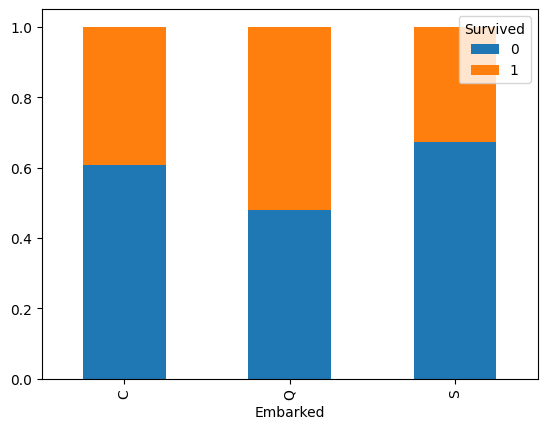

In [ ]:
pd.crosstab(df['Embarked'], df['Survived'], normalize='index').plot(kind='bar', stacked=True)
plt.show()

# Remove perfect feature

In [ ]:
df.drop('Sex', axis=1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,34.5,0,0,7.8292,NaN,Q
1,1,3,47.0,1,0,7.0000,NaN,S
2,0,2,62.0,0,0,9.6875,NaN,Q
3,0,3,27.0,0,0,8.6625,NaN,S
4,1,3,22.0,1,1,12.2875,NaN,S


# Feature Engineering

In [ ]:
# Combining two colums into one
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df.drop('SibSp', axis=1, inplace=True)
df.drop('Parch', axis=1, inplace=True)

def family_bin(s):
    if s == 1: return 'Alone'
    if s <= 4: return 'Small'
    else: return 'Large'

df['FamilyGroup'] = df['FamilySize'].apply(family_bin)

# Stable relationship between FamilyGroup feauture and the target

<Axes: xlabel='FamilySize', ylabel='Survived'>

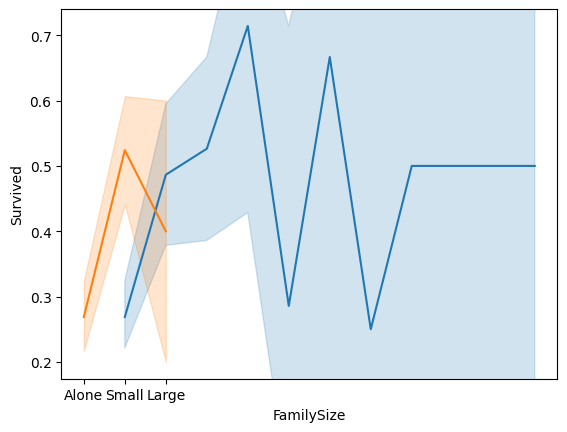

In [ ]:
sns.lineplot(data=df, x='FamilySize', y='Survived')
sns.lineplot(data=df, x='FamilyGroup', y='Survived')

In [ ]:
df.drop('FamilySize', axis=1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Age,Fare,Cabin,Embarked,FamilyGroup
0,0,3,34.5,7.8292,NaN,Q,Alone
1,1,3,47.0,7.0000,NaN,S,Small
2,0,2,62.0,9.6875,NaN,Q,Alone
3,0,3,27.0,8.6625,NaN,S,Alone
4,1,3,22.0,12.2875,NaN,S,Small


# Feature Selection



In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 99)

# Calculate percentage of missing values in training data only

In [ ]:
print('Percentage of null values:')
X_train.isnull().sum()/df.shape[0]*100

Percentage of null values:


,0
Pclass,0.000000
Age,14.114833
Fare,0.239234
Cabin,55.980861
Embarked,0.000000
FamilyGroup,0.000000


**Age and Fare percentage of missing values is below 50% . While Cabin is above 50%, drop the column.**

In [ ]:
X_train.drop('Cabin', axis=1, inplace=True)
X_test.drop('Cabin', axis=1, inplace=True)

# Handling missing values

**Fill age missing values with the median of the same group of pclass and age (median less affected by skewness than mean).**

In [ ]:
median_mapping = X_train.groupby('Pclass')['Age'].median()

X_train['Age'] = X_train['Age'].fillna(X_train['Pclass'].map(median_mapping))
X_test['Age'] = X_test['Age'].fillna(X_test['Pclass'].map(median_mapping))

**Fill fare missing values with median**

In [ ]:
train_fare_median = X_train['Fare'].median()

X_train['Fare'] = X_train['Fare'].fillna(train_fare_median)
X_test['Fare'] = X_test['Fare'].fillna(train_fare_median)

# Encoding

In [ ]:
X_train = pd.get_dummies(X_train, columns=['Embarked', 'FamilyGroup'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Embarked', 'FamilyGroup'], drop_first=True)
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

In [ ]:
X_train.head()

,Pclass,Age,Fare,Embarked_Q,Embarked_S,FamilyGroup_Large,FamilyGroup_Small
190,2,34.0,26.0000,False,True,False,True
246,2,22.0,21.0000,False,True,False,False
177,1,54.0,55.4417,False,False,False,True
4,3,22.0,12.2875,False,True,False,True
411,1,37.0,90.0000,True,False,False,True


# Undersampling

In [ ]:
y_train.value_counts()

,count
Survived,
0,190
1,102


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy={0:145,1:102}, random_state=42)
X_train, y_train = rus.fit_resample(X_train, y_train)

In [ ]:
model = DecisionTreeClassifier(class_weight='balanced', random_state=99)

param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Model Initialization with Class Balancing and Hyperparameter Tuning for Pruning

# Training

In [ ]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best Score: 0.6042537573168802


# Testing

In [ ]:
y_pred = best_model.predict(X_test)

# Cheching Overfitting Gap

In [ ]:
from sklearn.metrics import accuracy_score

train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy:     {test_accuracy:.2%}")

gap = train_accuracy - test_accuracy
print(f"Overfitting Gap:   {gap:.2%}")

Training Accuracy: 69.23%
Test Accuracy:     67.46%
Overfitting Gap:   1.77%


# Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.64      0.71        76
           1       0.57      0.72      0.64        50

    accuracy                           0.67       126
   macro avg       0.67      0.68      0.67       126
weighted avg       0.70      0.67      0.68       126



# Confusion Matrix

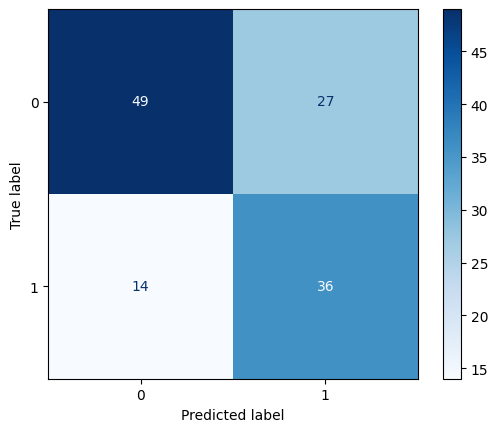

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.show()

# Feature Importances

Text(0.5, 1.0, 'Feature Importances')

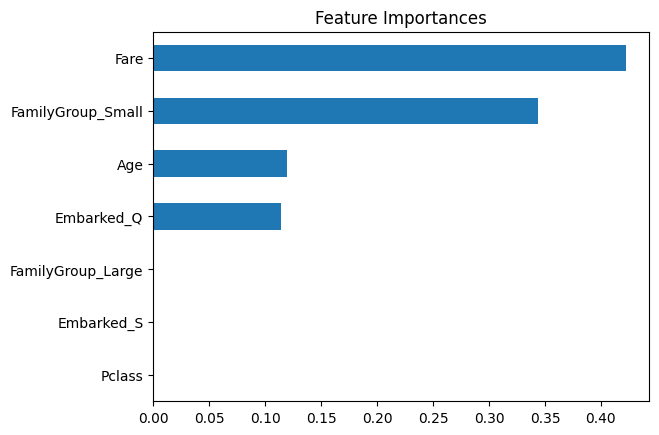

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)

importances.sort_values().plot(kind='barh')

plt.title('Feature Importances')